# 02 — Data Cleaning
**FIFA 2026 World Cup Predictor**

Cleans raw scraped data into analysis-ready CSVs:
- Strips whitespace from team names
- Removes the 1938 Sweden–Austria walkover (not a real match)
- Parses `Score` string → `HomeGoals`, `AwayGoals` integers
- Adds `TotalGoals` column
- Validates types and exports clean files


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# Load raw historical data
df_raw = pd.read_csv("data/raw_historical_data.csv") 
print("Raw historical shape:", df_raw.shape)
df_raw.head()

Raw historical shape: (929, 4)


,Home,Score,Away,year
0,France,4–1,Mexico,1930
1,Argentina,1–0,France,1930
2,Chile,3–0,Mexico,1930
3,Chile,1–0,France,1930
4,Argentina,6–3,Mexico,1930


In [19]:
df_raw['Score'] = df_raw['Score'].str.replace('[^\d-]', ' ' , regex=True).str.strip()
df_raw[['HomeGoals','AwayGoals']] = df_raw['Score'].str.split(' ', expand=True)
df_raw.drop('Score', axis=1, inplace=True)
df_raw.head()

,Home,Away,year,HomeGoals,AwayGoals
0,France,Mexico,1930,4,1
1,Argentina,France,1930,1,0
2,Chile,Mexico,1930,3,0
3,Chile,France,1930,1,0
4,Argentina,Mexico,1930,6,3


In [22]:
df_raw.rename(columns={'Home': 'HomeTeam', 'Away': 'AwayTeam', 'year': 'Year'}, inplace=True)
df_raw.head()

,HomeTeam,AwayTeam,Year,HomeGoals,AwayGoals
0,France,Mexico,1930,4,1
1,Argentina,France,1930,1,0
2,Chile,Mexico,1930,3,0
3,Chile,France,1930,1,0
4,Argentina,Mexico,1930,6,3


## 1. Inspect nulls and types

In [24]:
print("=== Null counts ===")
print(df_raw.isnull().sum())
print()
print("=== dtypes ===")
print(df_raw.dtypes)

=== Null counts ===
HomeTeam     0
AwayTeam     0
Year         0
HomeGoals    0
AwayGoals    1
dtype: int64

=== dtypes ===
HomeTeam     object
AwayTeam     object
Year          int64
HomeGoals    object
AwayGoals    object
dtype: object


## 2. Clean historical data

In [26]:
df = df_raw.copy()

# Strip whitespace
df["HomeTeam"] = df["HomeTeam"].str.strip()
df["AwayTeam"] = df["AwayTeam"].str.strip()

# Drop nulls
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df)} null rows")

# Remove 1938 Sweden–Austria walkover (Austria withdrew, not a real match)
mask = df["HomeTeam"].str.contains("Sweden") & df["AwayTeam"].str.contains("Austria")
print(f"Walkovers removed: {mask.sum()} (Sweden vs Austria 1938)")
df = df[~mask].copy()

# Ensure goal columns are integers
df = df.astype({"HomeGoals": int, "AwayGoals": int, "Year": int})

# Add TotalGoals
df["TotalGoals"] = df["HomeGoals"] + df["AwayGoals"]

df.reset_index(drop=True, inplace=True)
print(f"\nClean shape: {df.shape}")
df.head()

Dropped 1 null rows
Walkovers removed: 0 (Sweden vs Austria 1938)

Clean shape: (928, 6)


,HomeTeam,AwayTeam,Year,HomeGoals,AwayGoals,TotalGoals
0,France,Mexico,1930,4,1,5
1,Argentina,France,1930,1,0,1
2,Chile,Mexico,1930,3,0,3
3,Chile,France,1930,1,0,1
4,Argentina,Mexico,1930,6,3,9


## 3. Validate — matches per year

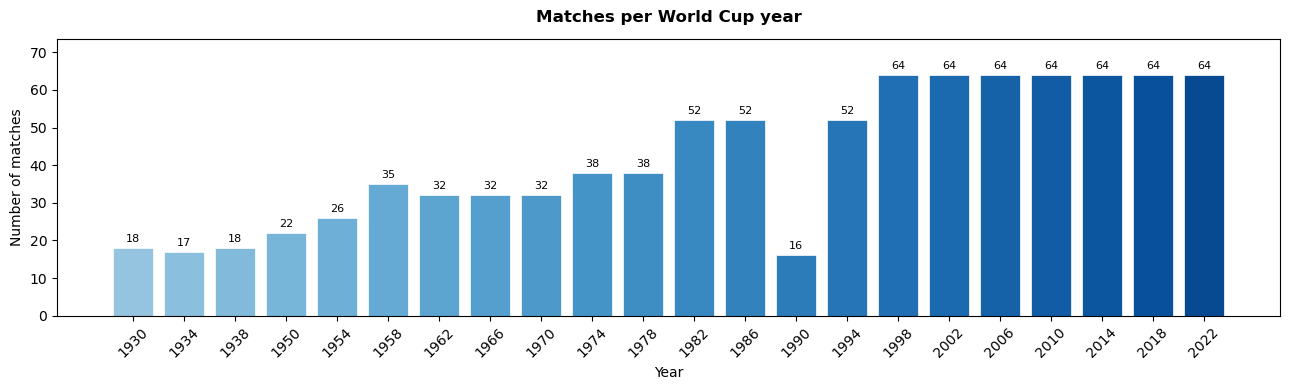

 Year  Matches
 1930       18
 1934       17
 1938       18
 1950       22
 1954       26
 1958       35
 1962       32
 1966       32
 1970       32
 1974       38
 1978       38
 1982       52
 1986       52
 1990       16
 1994       52
 1998       64
 2002       64
 2006       64
 2010       64
 2014       64
 2018       64
 2022       64


In [27]:
matches_per_year = df.groupby("Year").size().reset_index(name="Matches")

fig, ax = plt.subplots(figsize=(13, 4))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(matches_per_year)))
bars = ax.bar(matches_per_year["Year"].astype(str), matches_per_year["Matches"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title("Matches per World Cup year", fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, matches_per_year["Matches"].max() * 1.15)
plt.tight_layout()
plt.savefig("outputs/matches_per_year.png", dpi=140, bbox_inches="tight")
plt.show()
print(matches_per_year.to_string(index=False))

## 4. Validate — goals over time

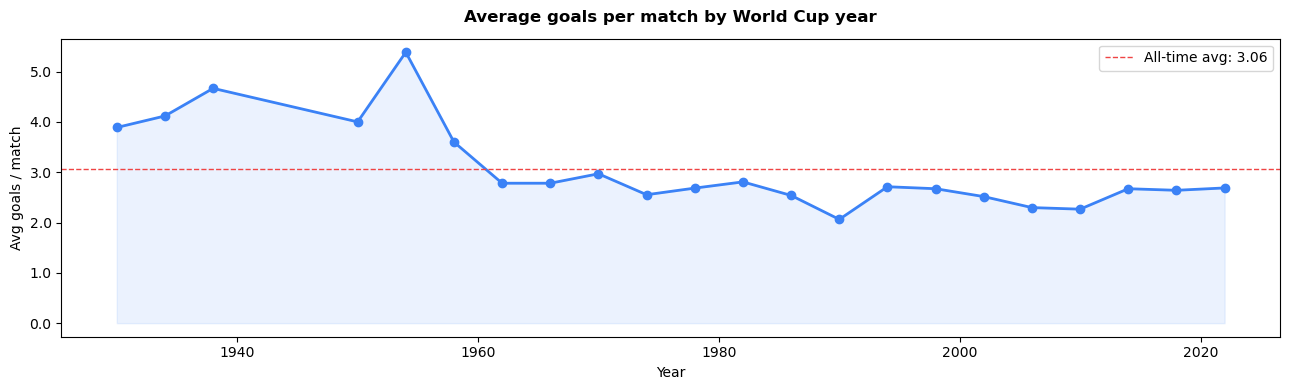

In [28]:
avg_goals = df.groupby("Year")["TotalGoals"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(avg_goals.index, avg_goals.values, "o-", color="#3b82f6", linewidth=2, markersize=6)
ax.fill_between(avg_goals.index, avg_goals.values, alpha=0.1, color="#3b82f6")
ax.axhline(avg_goals.mean(), color="#ef4444", linestyle="--", linewidth=1, label=f"All-time avg: {avg_goals.mean():.2f}")
ax.set_title("Average goals per match by World Cup year", fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Avg goals / match")
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
plt.tight_layout()
plt.savefig("outputs/avg_goals_per_year.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Outcome distribution

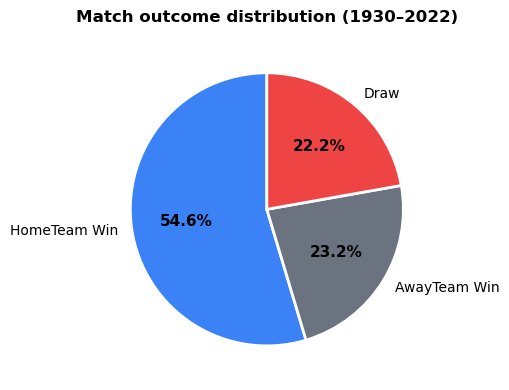

Outcome
HomeTeam Win    507
AwayTeam Win    215
Draw            206
Name: count, dtype: int64


In [29]:
df["Outcome"] = df.apply(
    lambda r: "HomeTeam Win" if r["HomeGoals"] > r["AwayGoals"]
    else ("Draw" if r["HomeGoals"] == r["AwayGoals"] else "AwayTeam Win"),
    axis=1
)
outcome_counts = df["Outcome"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
colors_pie = ["#3b82f6", "#6b7280", "#ef4444"]
wedges, texts, autotexts = ax.pie(
    outcome_counts.values,
    labels=outcome_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax.set_title("Match outcome distribution (1930–2022)", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/outcome_distribution.png", dpi=140, bbox_inches="tight")
plt.show()
print(outcome_counts)

## 6. Top scorers (teams)

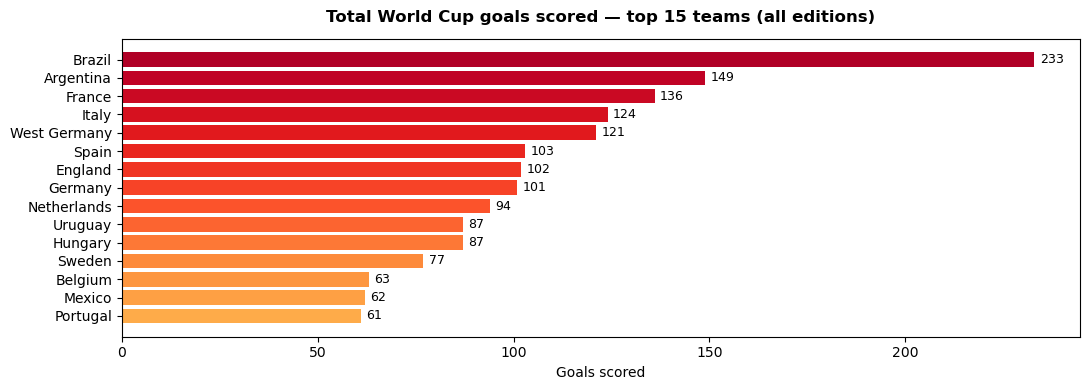

In [30]:
# Total goals scored as HomeTeam + AwayTeam combined
HomeTeam_goals = df.groupby("HomeTeam")["HomeGoals"].sum()
AwayTeam_goals = df.groupby("AwayTeam")["AwayGoals"].sum()
total_goals = (HomeTeam_goals.add(AwayTeam_goals, fill_value=0)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 4))
colors_bar = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(total_goals)))[::-1]
bars = ax.barh(total_goals.index[::-1], total_goals.values[::-1], color=colors_bar[::-1])
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title("Total World Cup goals scored — top 15 teams (all editions)", fontweight="bold", pad=12)
ax.set_xlabel("Goals scored")
plt.tight_layout()
plt.savefig("outputs/top_scorers.png", dpi=140, bbox_inches="tight")
plt.show()

## 7. Clean fixture

In [33]:
# Load raw fixture data
df_fix = pd.read_csv("data/raw_fixture_2026.csv")
print("Fixture shape:", df_fix.shape)
df_fix.head()

Fixture shape: (104, 4)


,Home,Score,Away,year
0,Mexico,Match 1,South Africa,2026
1,South Korea,Match 2,UEFA Path Dwinner,2026
2,UEFA Path Dwinner,Match 25,South Africa,2026
3,Mexico,Match 28,South Korea,2026
4,UEFA Path Dwinner,Match 53,Mexico,2026


In [34]:
df_fix.rename(columns={'Home': 'HomeTeam', 'Away': 'AwayTeam', 'year': 'Year'}, inplace=True)
df_fix.head()

,HomeTeam,Score,AwayTeam,Year
0,Mexico,Match 1,South Africa,2026
1,South Korea,Match 2,UEFA Path Dwinner,2026
2,UEFA Path Dwinner,Match 25,South Africa,2026
3,Mexico,Match 28,South Korea,2026
4,UEFA Path Dwinner,Match 53,Mexico,2026


In [35]:
df_fix["HomeTeam"] = df_fix["HomeTeam"].str.strip()
df_fix["AwayTeam"] = df_fix["AwayTeam"].str.strip()
print(f"Fixture: {len(df_fix)} rows")
df_fix.head(10)

Fixture: 104 rows


,HomeTeam,Score,AwayTeam,Year
0,Mexico,Match 1,South Africa,2026
1,South Korea,Match 2,UEFA Path Dwinner,2026
2,UEFA Path Dwinner,Match 25,South Africa,2026
3,Mexico,Match 28,South Korea,2026
4,UEFA Path Dwinner,Match 53,Mexico,2026
5,South Africa,Match 54,South Korea,2026
6,Canada,Match 3,UEFA Path Awinner,2026
7,Qatar,Match 8,Switzerland,2026
8,Switzerland,Match 26,UEFA Path Awinner,2026
9,Canada,Match 27,Qatar,2026


## 8. Save clean files

In [39]:
df.to_csv("data/historical_data.csv", index=False)
df_fix.to_csv("data/fixture_2026.csv", index=False)
print("Saved:")
print("  data/historical_data.csv")
print("  data/fixture_2026.csv")
print(f"\nFinal dataset: {len(df)} matches, {df['Year'].min()}–{df['Year'].max()}")
print(f"Unique teams: {len(set(df['HomeTeam']) | set(df['AwayTeam']))}")
print(f"Avg goals/match: {df['TotalGoals'].mean():.2f}")

Saved:
  data/historical_data.csv
  data/fixture_2026.csv

Final dataset: 928 matches, 1930–2022
Unique teams: 85
Avg goals/match: 2.84


## Summary

| Stat | Value |
|---|---|
| Total matches | 928 |
| Years covered | 1930 – 2022 |
| Unique teams | 85 |
| Avg goals/match | ~2.84 |
| HomeTeam win rate | ~54.6% |
| Draw rate | ~22.2% |
| AwayTeam win rate | ~23.2% |

